# Chapter 8: The Five-Stage Feature Engineering Process

**When the target is multiplicative and skewed, does fitting log1p(y) help, and does the answer depend on the metric and on how the prediction is brought back to the raw scale?**

A skewed target tempts a log transform, but the chapter warns that exponentiating a mean log prediction need not recover the raw-scale conditional mean. Measuring both metrics on the same new rows shows which policy each metric rewards.

*Constructed data with log-normal noise; the sizes of these gaps are properties of this generator. No policy wins every metric, and with this multiplicative noise the raw-target fit is never a clear winner.*

## The experiment

A constructed regression with 5 features and a log-normal target, y = exp(f(x) + s * noise), where the noise spread s is the control. A histogram gradient boosting regressor is trained on 6,000 rows under three policies: fit y directly; fit log1p(y) and take expm1 of the prediction; and fit log1p(y) with a smearing correction that averages expm1(m + e) over cross-fitted log residuals e. A constant (the training mean) is the simple predictor. Each is scored on 8,000 new rows from the same generator by raw-scale RMSE and by RMSLE, the square root of the mean squared difference of log1p values. Every score is the mean over 8 constructed datasets.

In [1]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold

from kaggle_companion.activities._common import clean

SEED = 8
REPLICATES = 8        # independent constructed datasets; every score is their mean
N_TRAIN, N_NEW = 6000, 8000


def generate(n, sigma, rng):
    """Five features; the target is multiplicative: y = exp(f(x) + sigma * noise). exp(f) is its median."""
    X = rng.normal(size=(n, 5))
    f = 3.0 + 0.8 * X[:, 0] + 0.5 * X[:, 1] - 0.4 * X[:, 2] + 0.3 * X[:, 0] * X[:, 1]
    y = np.exp(f + sigma * rng.normal(size=n))
    return X, y, f


def model():
    return HistGradientBoostingRegressor(max_iter=100, learning_rate=0.08, max_depth=3, min_samples_leaf=30, random_state=0)


def rmse(y, p):
    return float(np.sqrt(np.mean((y - p) ** 2)))


def rmsle(y, p):
    return float(np.sqrt(np.mean((np.log1p(y) - np.log1p(np.maximum(p, 0))) ** 2)))


def one_dataset(sigma, seed):
    rng = np.random.default_rng(seed)
    X, y, _ = generate(N_TRAIN, sigma, rng)
    X_new, y_new, f_new = generate(N_NEW, sigma, rng)

    raw = model().fit(X, y).predict(X_new)                     # policy 1: fit y directly, squared error on the raw scale

    log_y = np.log1p(y)                                         # policy 2: fit log1p(y), then undo the transform
    m_new = model().fit(X, log_y).predict(X_new)                # predicted mean of log1p(y)
    naive = np.expm1(m_new)                                     # exponentiate the mean log prediction
    oof = np.zeros(N_TRAIN)                                     # policy 3: smearing. Cross-fitted log residuals e_i give
    for a, b in KFold(5, shuffle=True, random_state=0).split(X):  # mean(expm1(m + e_i)) = exp(m) * mean(exp(e_i)) - 1
        oof[b] = model().fit(X[a], log_y[a]).predict(X[b])
    smear = np.exp(m_new) * np.mean(np.exp(log_y - oof)) - 1.0

    policies = {"raw_fit": raw, "log_naive": naive, "log_smeared": smear, "constant": np.full(N_NEW, y.mean())}
    out = {k: {"rmse": rmse(y_new, p), "rmsle": rmsle(y_new, p), "mean_prediction": float(np.mean(p))}
           for k, p in policies.items()}
    out["known_mean"] = {"rmse": rmse(y_new, np.exp(f_new + sigma ** 2 / 2)), "rmsle": rmsle(y_new, np.exp(f_new + sigma ** 2 / 2))}
    out["known_median"] = {"rmse": rmse(y_new, np.exp(f_new)), "rmsle": rmsle(y_new, np.exp(f_new))}
    out["mean_target"] = float(np.mean(y_new))
    return out


def run(sigma):
    sets = [one_dataset(sigma, SEED * 100 + i) for i in range(REPLICATES)]
    result = {"sigma": sigma, "replicates": REPLICATES, "training_rows": N_TRAIN, "new_rows": N_NEW,
              "mean_target": float(np.mean([s["mean_target"] for s in sets]))}
    for name in ("raw_fit", "log_naive", "log_smeared", "constant", "known_mean", "known_median"):
        result[name] = {m: float(np.mean([s[name][m] for s in sets])) for m in sets[0][name]}
        result[name]["rmse_per_set"] = [s[name]["rmse"] for s in sets]
        result[name]["rmsle_per_set"] = [s[name]["rmsle"] for s in sets]
    return clean(result)


## Measure it across the control

The control is **multiplicative noise spread s (standard deviation of the log-scale noise)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch08 import explain

VALUES = [0.3, 0.8, 1.2, 1.6]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                  0.3    0.8    1.2     1.6
RMSLE, plain log fit            0.297  0.749  1.099   1.433
RMSLE, raw-target fit           0.679  1.034  1.468   2.014
RMSE, plain log fit              93.8  213.1  530.5  1864.3
RMSE, smeared log fit            92.0  203.4  510.0  1829.3
RMSE, raw-target fit            102.9  214.3  524.2  1854.9
Mean prediction, plain log fit   38.8   39.2   39.7    40.7


## Look at it

The figure shows the default setting, multiplicative noise spread s (standard deviation of the log-scale noise) = 0.8.

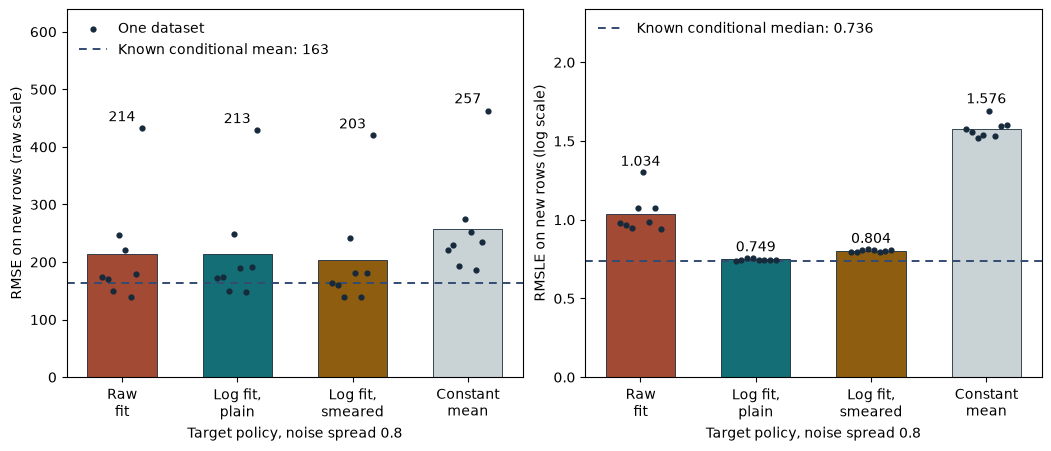

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch08 import draw, NCOLS, HEIGHT

DEFAULT = 0.8
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

At noise spread 0.8, the plain log fit scores RMSLE 0.749 (raw-target fit 1.034) but its predictions average 39.2 against a target mean of 58.6, so 39.2 / 58.6 = 0.669 of the mean is recovered. The smearing correction lowers RMSE from 213.1 to 203.4 and raises RMSLE from 0.749 to 0.804. The raw-target fit has RMSE 214.3 and the constant 256.7.

- Mean recovered by the plain back-transform: 39.2 / 58.6 = 0.669.
- Gain of smearing on RMSE: 213.1 - 203.4 = +9.7 (positive means smearing is better).
- Cost of smearing on RMSLE: 0.804 - 0.749 = +0.055 (positive means smearing is worse).
- Raw-target fit against the plain log fit on RMSLE: 1.034 - 0.749 = +0.286.

## Apply this to your competition

- Read which metric scores the competition before deciding whether to transform the target at all.
- If the metric is RMSLE or another log-scale loss, fit log1p(y) and invert it plainly; if it is raw-scale RMSE, test a smearing-style correction.
- Check the average of your predictions against the average of the training target; a large shortfall means the inverse policy is off.
- Keep a raw-target fit and a constant predictor as comparators, and choose the transform inside development, not on the assessment rows.

Book location: Chapter 8, Stage 4: Target Transforms.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)